# GTFS-RT

In [1]:
import pandas as pd

# maybe install pip install gtfs-realtime-bindings protobuf pandas
from google.transit import gtfs_realtime_pb2
from google.protobuf.json_format import MessageToDict

# Load .pb file
feed = gtfs_realtime_pb2.FeedMessage()

with open("GTFSR_20260217100801.pb", "rb") as f:
    feed.ParseFromString(f.read())

print(len(feed.entity))
import pandas as pd

records = []

for entity in feed.entity:
    if entity.HasField("trip_update"):
        trip = entity.trip_update.trip
        
        for stop_time in entity.trip_update.stop_time_update:
            
            record = {
                "trip_id": trip.trip_id,
                "route_id": trip.route_id,
                "stop_id": stop_time.stop_id,
                "arrival_delay": (
                    stop_time.arrival.delay 
                    if stop_time.HasField("arrival") else None
                ),
                "departure_delay": (
                    stop_time.departure.delay 
                    if stop_time.HasField("departure") else None
                )
            }
            
            records.append(record)

df_rt = pd.DataFrame(records)
df_rt["arrival_delay_min"] = df_rt["arrival_delay"] / 60
#print(df_rt[df_rt["arrival_delay_min"]  > 0.0])

stop_times = pd.read_csv("stop_times.txt")

df = df_rt.merge(
    stop_times,
    on=["trip_id", "stop_id"],
    how="left"
)

df["delay_min"] = df["arrival_delay"] / 60
df = df[df["delay_min"].notna()]
df = df.sort_values(["trip_id", "stop_sequence"])

df["prev_delay"] = (
    df.groupby("trip_id")["delay_min"]
    .shift(1)
)






11397


In [2]:
df

,trip_id,route_id,stop_id,arrival_delay,departure_delay,arrival_delay_min,arrival_time,departure_time,stop_sequence,pickup_type,drop_off_type,delay_min,prev_delay
149025,1.TA.91-10-A-j26-1.1.H,91-10-A-j26-1,8503053:0:1,24.0,54.0,0.4,09:08:00,09:08:00,2.0,0.0,0.0,0.4,NaN
149026,1.TA.91-10-A-j26-1.1.H,91-10-A-j26-1,8503052:0:1,24.0,54.0,0.4,09:09:00,09:09:00,3.0,0.0,0.0,0.4,0.4
149027,1.TA.91-10-A-j26-1.1.H,91-10-A-j26-1,8503051:0:1,-6.0,24.0,-0.1,09:12:00,09:12:00,4.0,0.0,0.0,-0.1,0.4
149028,1.TA.91-10-A-j26-1.1.H,91-10-A-j26-1,8503090:0:1,18.0,42.0,0.3,09:15:00,09:15:00,5.0,0.0,0.0,0.3,-0.1
149029,1.TA.91-10-A-j26-1.1.H,91-10-A-j26-1,8503000:0:22,12.0,NaN,0.2,09:17:00,09:17:00,6.0,0.0,0.0,0.2,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15409,ojp:96301:1:H:j26.85:801_85:801:3011_85:801:88...,96-301-1-j26-1,8509869:0:10000,252.0,252.0,4.2,NaN,NaN,NaN,NaN,NaN,4.2,NaN
15410,ojp:96301:1:H:j26.85:801_85:801:3011_85:801:88...,96-301-1-j26-1,8509798,252.0,252.0,4.2,NaN,NaN,NaN,NaN,NaN,4.2,4.2
15411,ojp:96301:1:H:j26.85:801_85:801:3011_85:801:88...,96-301-1-j26-1,8581567:0:10000,252.0,252.0,4.2,NaN,NaN,NaN,NaN,NaN,4.2,4.2
15412,ojp:96301:1:H:j26.85:801_85:801:3011_85:801:88...,96-301-1-j26-1,1300074,252.0,252.0,4.2,NaN,NaN,NaN,NaN,NaN,4.2,4.2


min Delay: -89.4: max Delay: 90.0


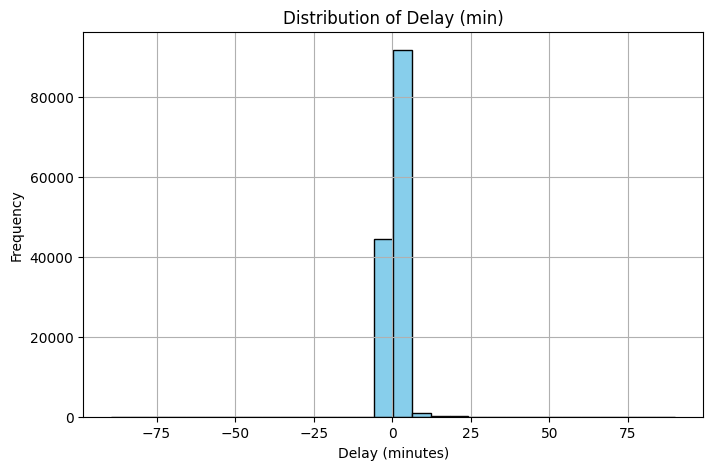

In [7]:
# DF analyzes

import matplotlib.pyplot as plt

print(f"min Delay: {min(df['delay_min'])}: max Delay: {max(df['delay_min'])}")

plt.figure(figsize=(8, 5))
plt.hist(df['delay_min'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Delay (min)')
plt.xlabel('Delay (minutes)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

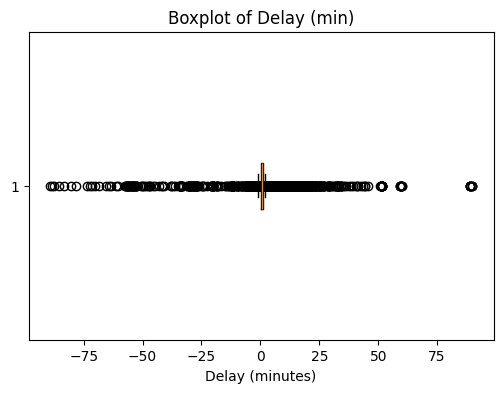

In [8]:
plt.figure(figsize=(6, 4))
plt.boxplot(df['delay_min'], vert=False)
plt.title('Boxplot of Delay (min)')
plt.xlabel('Delay (minutes)')
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

features = [
    "stop_sequence",
    "prev_delay"
]

df = df.dropna(subset=features + ["delay_min"])

X = df[features]
y = df["delay_min"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = RandomForestRegressor()
model.fit(X_train, y_train)

print("Score:", model.score(X_test, y_test))

# Weather only

In [15]:
weather_df = pd.read_csv("test_weather_data.csv", delimiter=";", header=0)


weather_df['hour'] = pd.to_datetime(weather_df['reference_timestamp'], format='%d.%m.%Y %H:%M').dt.hour
weather_df

,station_abbr,reference_timestamp,tre200h0,tre200hn,tre200hx,tre005h0,tre005hn,ure200h0,pva200h0,tde200h0,...,oli000h0,olo000h0,osr000h0,ods000h0,sre000h0,erefaoh0,tso005hs,tso010hs,tso020hs,hour
0,RUE,18.02.2026 00:00,-0.2,-0.4,-0.1,-4.2,-4.3,75.8,4.6,-3.9,...,222,NaN,NaN,0,0,0.004,NaN,NaN,NaN,0
1,RUE,18.02.2026 01:00,0.1,-0.1,0.4,-4.1,-4.4,67.8,4.2,-5.1,...,229,NaN,NaN,0,0,0.003,NaN,NaN,NaN,1
2,RUE,18.02.2026 02:00,0.5,0.4,0.6,-3.8,-4.0,64.0,4.1,-5.5,...,229,NaN,NaN,0,0,-0.005,NaN,NaN,NaN,2
3,RUE,18.02.2026 03:00,0.1,-0.2,0.6,-3.7,-3.8,69.4,4.3,-4.8,...,235,NaN,NaN,1,0,0.000,NaN,NaN,NaN,3
4,RUE,18.02.2026 04:00,-0.2,-0.8,0.3,-2.5,-3.0,74.6,4.5,-4.1,...,257,NaN,NaN,0,0,0.004,NaN,NaN,NaN,4
5,RUE,18.02.2026 05:00,0.1,-0.1,0.3,-1.7,-1.9,77.4,4.7,-3.4,...,281,NaN,NaN,0,0,0.000,NaN,NaN,NaN,5
6,RUE,18.02.2026 06:00,-0.2,-0.4,0.0,-1.7,-2.0,78.8,4.7,-3.4,...,283,NaN,NaN,1,0,0.001,NaN,NaN,NaN,6
7,RUE,18.02.2026 07:00,0.2,-0.5,0.9,-0.9,-1.3,81.5,5.1,-2.6,...,294,NaN,NaN,4,0,-0.007,NaN,NaN,NaN,7
8,RUE,18.02.2026 08:00,0.8,0.5,1.2,0.8,0.4,84.7,5.5,-1.5,...,310,NaN,NaN,39,0,0.022,NaN,NaN,NaN,8
9,RUE,18.02.2026 09:00,0.7,0.2,1.1,0.8,0.5,91.5,5.9,-0.5,...,317,NaN,NaN,49,0,0.028,NaN,NaN,NaN,9
